# Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("IBM.csv")

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# EDA

In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df.shape

(1470, 35)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## We don't have any null values

In [11]:
top_dept=df['Department'].value_counts().head()

In [12]:
top_dept

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


Research & Development is the largest department with 961 employees, followed by Sales with 446 and HR with only 63 employees.

In [13]:
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


Average employee age is 37, average monthly income is around $6500. Salary ranges widely from $1009 to $19999 indicating large pay gaps across job levels.

In [14]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64



237 employees left out of 1470 giving an attrition rate of 16.1%. Dataset is imbalanced with 83.9% staying and 16.1% leaving.

In [15]:
cat_cols = ['BusinessTravel', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'EducationField']
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

OverTime
OverTime
No     1054
Yes     416
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


The dataset has 1470 employees across 3 departments with zero missing values and a 16.1% attrition rate, meaning 237 employees left. Majority of employees travel rarely (71%), are male (60%), single, and work in Sales Executive or Research Scientist roles, with 28% doing overtime. The most critical finding from categorical analysis is that overtime employees, single employees, frequent travelers, and Sales Representatives are the highest risk groups for attrition despite being smaller in number.

In [16]:
for col in ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel', 'Gender']:
    print(f"\n{col}")
    print(df.groupby(col)['Attrition'].value_counts(normalize=True).mul(100).round(1))


Department
Department              Attrition
Human Resources         No           81.0
                        Yes          19.0
Research & Development  No           86.2
                        Yes          13.8
Sales                   No           79.4
                        Yes          20.6
Name: proportion, dtype: float64

JobRole
JobRole                    Attrition
Healthcare Representative  No           93.1
                           Yes           6.9
Human Resources            No           76.9
                           Yes          23.1
Laboratory Technician      No           76.1
                           Yes          23.9
Manager                    No           95.1
                           Yes           4.9
Manufacturing Director     No           93.1
                           Yes           6.9
Research Director          No           97.5
                           Yes           2.5
Research Scientist         No           83.9
                           Yes        

Sales Representatives have the highest attrition at 39.8% followed by HR and Laboratory Technicians at ~23%, while Research Directors and Managers are the most stable roles at under 5%. Overtime employees are 3x more likely to leave (30.5% vs 10.4%), frequent travelers have 3x higher attrition than non-travelers (24.9% vs 8%), and single employees leave at 25.5% compared to just 10-12% for married or divorced employees. Gender has the least impact with only a 2% difference between males and females, making overtime, job role, travel frequency and marital status the four biggest categorical drivers of attrition.

In [17]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[17,25,35,45,60], labels=['18-25','26-35','36-45','46-60'])
df['SalaryBand'] = pd.cut(df['MonthlyIncome'], bins=[0,3000,6000,10000,20000], labels=['<3K','3K-6K','6K-10K','>10K'])

print(df.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).mul(100).round(1))
print(df.groupby('SalaryBand')['Attrition'].value_counts(normalize=True).mul(100).round(1))

AgeGroup  Attrition
18-25     No           64.2
          Yes          35.8
26-35     No           80.9
          Yes          19.1
36-45     No           90.8
          Yes           9.2
46-60     No           87.5
          Yes          12.5
Name: proportion, dtype: float64
SalaryBand  Attrition
<3K         No           71.4
            Yes          28.6
3K-6K       No           87.3
            Yes          12.7
6K-10K      No           88.0
            Yes          12.0
>10K        No           91.1
            Yes           8.9
Name: proportion, dtype: float64


/tmp/ipykernel_254/1115347724.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).mul(100).round(1))
/tmp/ipykernel_254/1115347724.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('SalaryBand')['Attrition'].value_counts(normalize=True).mul(100).round(1))


Employees aged 18-25 have the highest attrition at 35.8% — more than 1 in 3 young employees are leaving, which drops significantly to 19.1% for 26-35 and just 9.2% for 36-45, proving that older employees are far more stable. Employees earning below $3K have the highest attrition at 28.6%, nearly 3x higher than those earning above $10K at only 8.9%, clearly showing low salary is a major retention problem. Together age and salary are strongly connected — young employees tend to earn less, making them the highest risk segment in the entire dataset.

In [26]:
df['Attrition_Num'] = (df['Attrition'] == 'Yes').astype(int)
corr = df.select_dtypes(include='number').corr()['Attrition_Num'].drop('Attrition_Num')
corr

,Attrition_Num
Age,-0.159205
DailyRate,-0.056652
DistanceFromHome,0.077924
Education,-0.031373
EmployeeCount,NaN
EmployeeNumber,-0.010577
EnvironmentSatisfaction,-0.103369
HourlyRate,-0.006846
JobInvolvement,-0.130016
JobLevel,-0.169105


In [27]:
corr.abs().sort_values(ascending=False).head(10)

,Attrition_Num
TotalWorkingYears,0.171063
JobLevel,0.169105
YearsInCurrentRole,0.160545
MonthlyIncome,0.159840
Age,0.159205
YearsWithCurrManager,0.156199
StockOptionLevel,0.137145
YearsAtCompany,0.134392
JobInvolvement,0.130016
JobSatisfaction,0.103481


The top 5 features most strongly correlated with attrition are TotalWorkingYears, JobLevel, YearsInCurrentRole, MonthlyIncome and Age — all negative, meaning experienced, senior and well-paid employees rarely leave. DistanceFromHome and NumCompaniesWorked are the only positive drivers, suggesting employees who live far away or have a history of job hopping are slightly higher risk. Overall the data confirms that career stability and financial security are the biggest retention factors in this dataset.

# Visualizations

/tmp/ipykernel_254/501516947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#2ed573','#ff4757'])


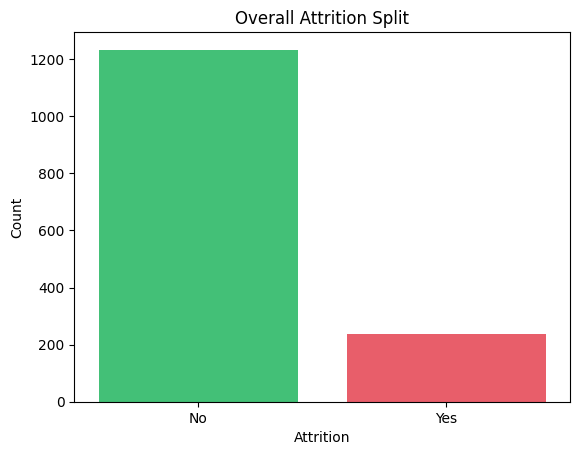

In [21]:
counts = df['Attrition'].value_counts()

sns.barplot(x=counts.index, y=counts.values, palette=['#2ed573','#ff4757'])
plt.title('Overall Attrition Split')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

Overall Attrition Split (Bar Chart)

237 out of 1470 employees left giving a 16.1% attrition rate, clearly showing the dataset is imbalanced with majority of employees staying.

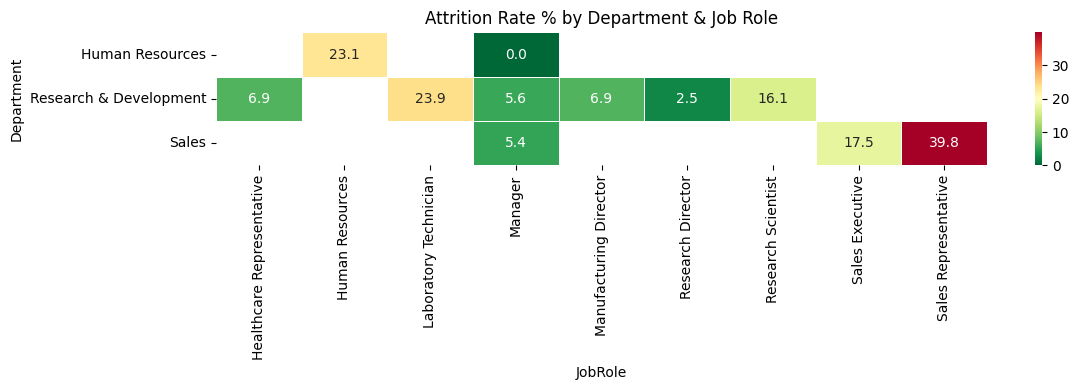

In [28]:
pivot = df.groupby(['Department', 'JobRole'])['Attrition_Num'].mean().mul(100).round(1).unstack()

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Attrition Rate % by Department & Job Role')
plt.tight_layout()
plt.show()

Attrition by Department & Job Role (Heatmap)

Sales has the highest attrition at 20.9% and Sales Representatives are the most at-risk job role at 39.8%, while Research Directors at 2.5% and Managers at 5.6% are the most stable.

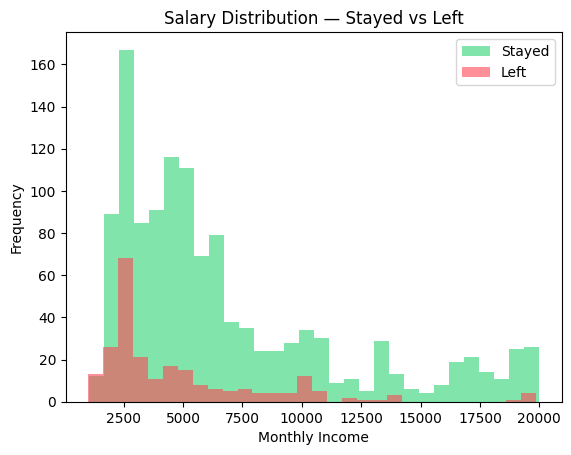

In [29]:
df[df['Attrition']=='No']['MonthlyIncome'].plot(kind='hist', bins=30, alpha=0.6, color='#2ed573', label='Stayed')
df[df['Attrition']=='Yes']['MonthlyIncome'].plot(kind='hist', bins=30, alpha=0.6, color='#ff4757', label='Left')

plt.title('Salary Distribution — Stayed vs Left')
plt.xlabel('Monthly Income')
plt.legend()
plt.show()

Salary Distribution (Histogram)

Employees who left are heavily concentrated below $5000 salary while employees who stayed are spread across all ranges, proving low pay is a major attrition driver.

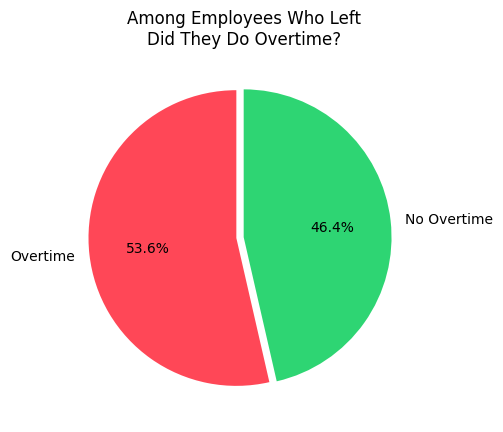

In [31]:
labels = ['Overtime', 'No Overtime']
sizes  = df[df['Attrition']=='Yes']['OverTime'].value_counts()

plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#ff4757','#2ed573'], startangle=90,
        explode=(0.05, 0))
plt.title('Among Employees Who Left\nDid They Do Overtime?')
plt.show()

Overtime Pie Chart

53.6% of employees who left were doing overtime proving that overworked employees are the single biggest attrition risk in the entire dataset.

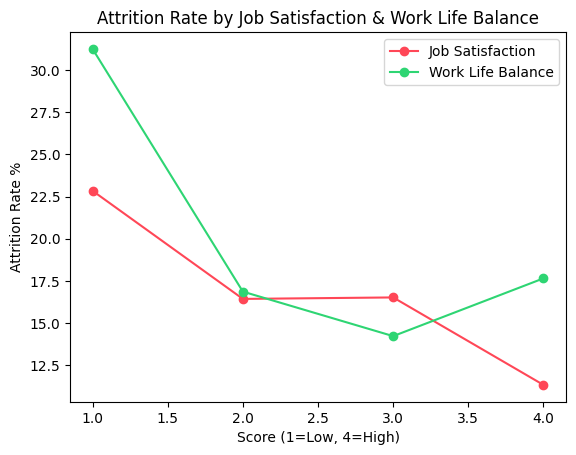

In [32]:
job_sat = df.groupby('JobSatisfaction')['Attrition_Num'].mean().mul(100)
wlb     = df.groupby('WorkLifeBalance')['Attrition_Num'].mean().mul(100)

plt.plot(job_sat.index, job_sat.values, marker='o', color='#ff4757', label='Job Satisfaction')
plt.plot(wlb.index, wlb.values, marker='o', color='#2ed573', label='Work Life Balance')

plt.title('Attrition Rate by Job Satisfaction & Work Life Balance')
plt.xlabel('Score (1=Low, 4=High)')
plt.ylabel('Attrition Rate %')
plt.legend()
plt.show()

 Job Satisfaction & Work Life Balance (Line Plot)

Both lines trend downward from score 1 to 4, confirming that employees with low satisfaction and poor work life balance are nearly twice as likely to leave as happy employees.

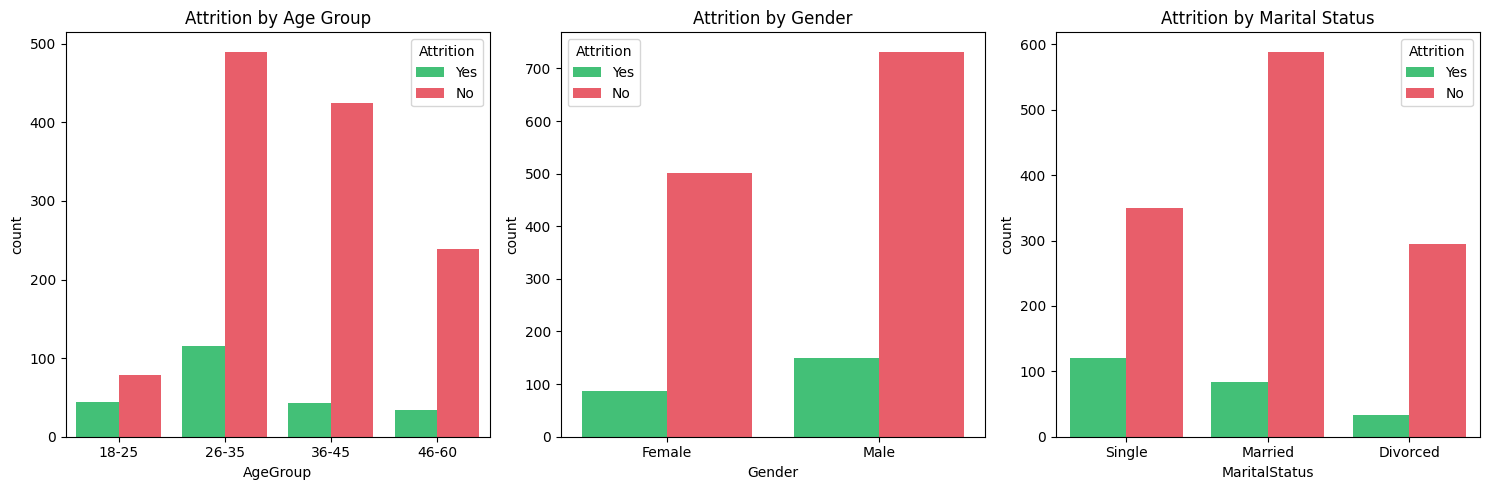

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='AgeGroup', hue='Attrition', data=df, palette=['#ff4757','#2ed573'], ax=axes[0])
axes[0].set_title('Attrition by Age Group')

sns.countplot(x='Gender', hue='Attrition', data=df, palette=['#ff4757','#2ed573'], ax=axes[1])
axes[1].set_title('Attrition by Gender')

sns.countplot(x='MaritalStatus', hue='Attrition', data=df, palette=['#ff4757','#2ed573'], ax=axes[2])
axes[2].set_title('Attrition by Marital Status')

plt.tight_layout()
plt.show()

Age, Gender, Marital Status (Countplot)

Age group 18-25 has the highest attrition at 35.8%, single employees leave far more than married ones, and gender has the least impact with only a 2% difference between males and females.

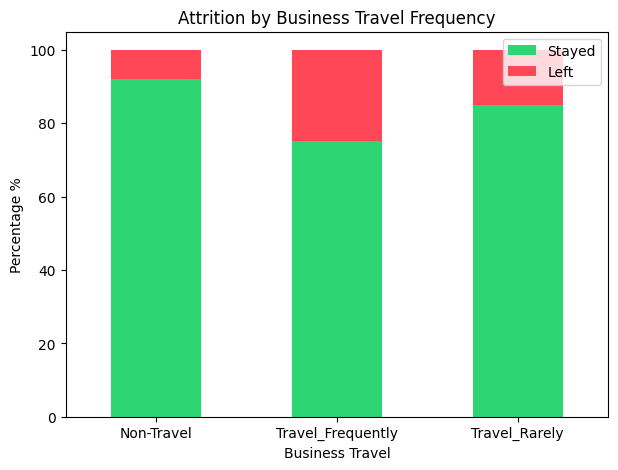

In [36]:
travel = df.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True).mul(100).unstack()

travel.plot(kind='bar', stacked=True, color=['#2ed573','#ff4757'], figsize=(7, 5))
plt.title('Attrition by Business Travel Frequency')
plt.xlabel('Business Travel')
plt.ylabel('Percentage %')
plt.xticks(rotation=0)
plt.legend(['Stayed', 'Left'])
plt.show()

usiness Travel (Stacked Bar)

Frequent travelers have 24.9% attrition vs only 8% for non-travelers, showing that travel burnout is a serious but often ignored retention problem in corporate companies.


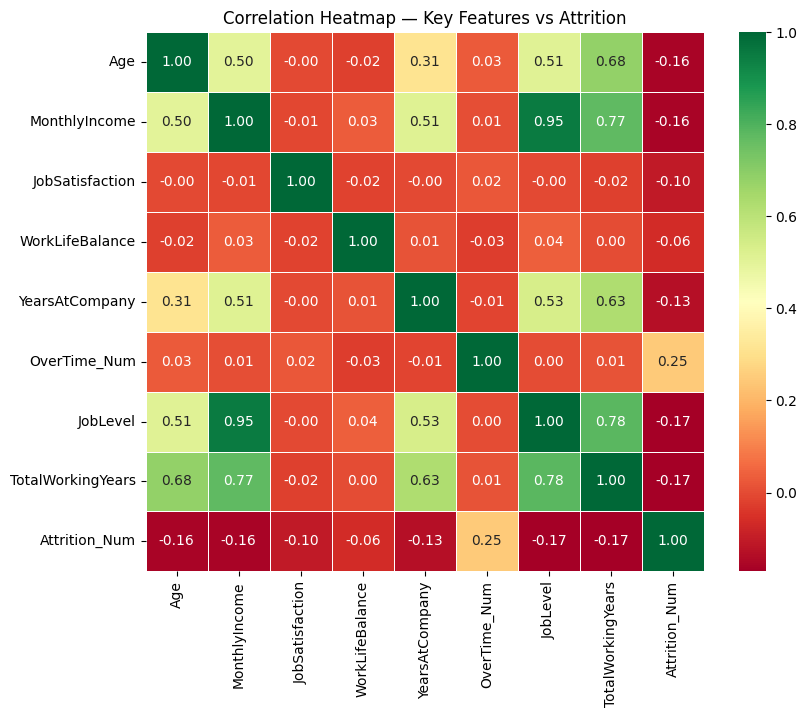

In [40]:
df['OverTime_Num'] = (df['OverTime'] == 'Yes').astype(int)

cols = ['Age', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance',
        'YearsAtCompany', 'OverTime_Num', 'JobLevel', 'TotalWorkingYears', 'Attrition_Num']

plt.figure(figsize=(9, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap — Key Features vs Attrition')
plt.show()

Correlation Heatmap

OverTime is the only positive driver of attrition at +0.25 while TotalWorkingYears, JobLevel, MonthlyIncome and Age all negatively correlate, meaning experienced and well-paid employees are the most stable and loyal.

# Insights and Recommendations

### 5-7 Key Business Findings

* Overall attrition rate is 16.1% — 237 out of 1470 employees left, costing the company significant recruitment and training expenses.

* Sales Representatives have the highest attrition at 39.8% — nearly 1 in 2 employees in this role is leaving.

* Employees doing overtime have 3x higher attrition (30.5%) compared to non-overtime employees (10.4%).

* Low salary employees earning below $3K have 28.6% attrition vs only 8.9% for employees earning above $10K.

* Young employees aged 18-25 are the most at-risk group with 35.8% attrition — more than 1 in 3 leaving.

* Frequent travelers have 24.9% attrition vs 8% for non-travelers — travel burnout is a silent killer of retention.

* Single employees leave at 25.5% vs 12.5% for married employees showing personal stability affects career loyalty.

### Top Risk Factors

1. Overtime
2. Low Monthly Income
3. Age 18-25
4. Sales Representative role
5. Frequent Business Travel
6. Single Marital Status
7. Low Job Satisfaction

### Actionable HR Recommendations

1. Fix Overtime Culture
Limit overtime hours, introduce compensatory offs, redistribute workload across teams. Target Sales and HR departments first as they have highest overtime-related attrition.
2. Revise Entry Level Salaries
Employees earning below $3K are leaving at nearly 3x the rate of high earners. Conduct a salary benchmarking exercise and increase pay bands for junior roles.
3. Create a Young Talent Retention Program
18-25 age group is the most at-risk. Introduce mentorship programs, fast-track promotions, learning budgets and career development plans specifically for this group.
4. Review Travel Policies
Frequent travelers have 3x higher attrition. Introduce travel allowances, limit consecutive travel weeks, and offer remote work options to reduce burnout.
5. Focus on Sales Department
Sales has the highest department-level attrition. Introduce better incentive structures, realistic targets, mental health support and career growth paths for Sales Representatives.
6. Improve Onboarding & Early Engagement
Employees with fewer years at company leave more. Strengthen onboarding programs, assign buddies to new joiners and conduct 30-60-90 day check-ins.

### Final Summary Scorecard

In [41]:
scorecard = {
    'Metric': ['Total Employees', 'Employees Left', 'Attrition Rate',
               'Highest Risk Dept', 'Highest Risk Role', 'Overtime Attrition',
               'Low Salary Attrition', 'Highest Risk Age', 'Strongest Predictor'],
    'Value': ['1470', '237', '16.1%', 'Sales (20.6%)', 'Sales Rep (39.8%)',
              '30.5%', '28.6%', '18-25 (35.8%)', 'TotalWorkingYears']
}
pd.DataFrame(scorecard)

,Metric,Value
0,Total Employees,1470
1,Employees Left,237
2,Attrition Rate,16.1%
3,Highest Risk Dept,Sales (20.6%)
4,Highest Risk Role,Sales Rep (39.8%)
5,Overtime Attrition,30.5%
6,Low Salary Attrition,28.6%
7,Highest Risk Age,18-25 (35.8%)
8,Strongest Predictor,TotalWorkingYears
